In [ ]:
# HEART DISEASE PREDICTION
## OBJECTIVE
The goal is to build a machine learning model that predicts whether a person is at risk of heart disease based on medical attributes.
This is a binary classification problem where:
- 0 → No disease
- 1 → Disease present

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

In [3]:
# LOADING DATASET FROM LOCAL PATH
df = pd.read_csv(r'C:\Users\hp\Downloads\heart.csv')
# DISPLAYING FIRST 5 ROWS
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
# CHECKING FOR MISSING VALUES
print(df.isnull().sum())

# IF MISSING VALUE IS PRESENT DROP IT
df = df.dropna()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


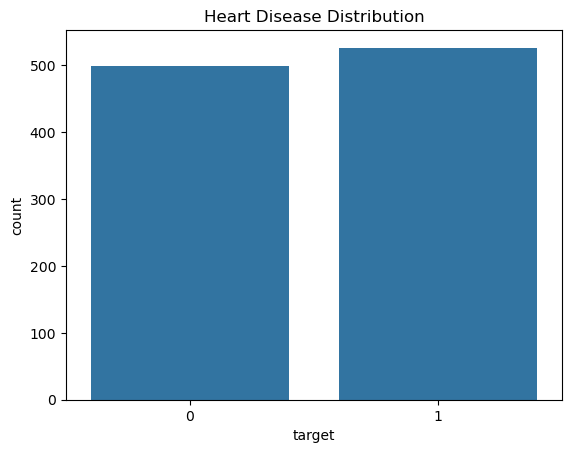

In [7]:
# EDA PLOT DISTIBUTION OF TARGET VARIABLE 0 OR 1 
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

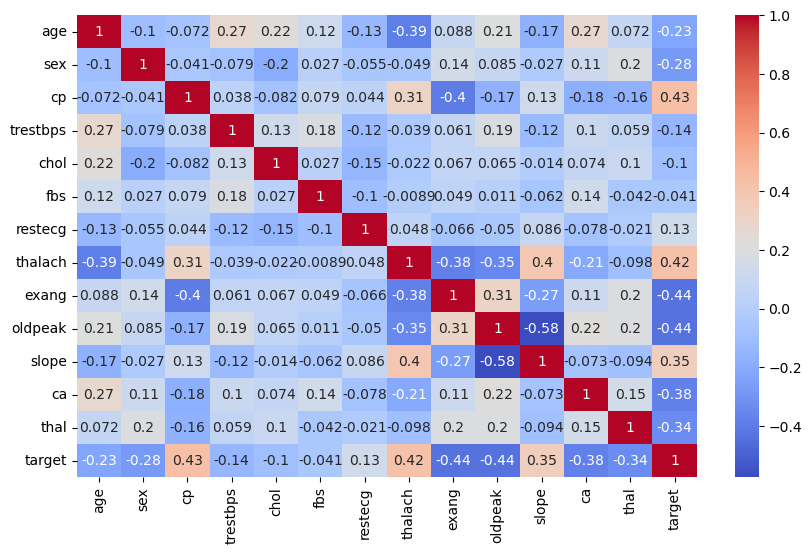

In [9]:
# CORRELATION HEATMAP TO SEE THE RELATIONSHIP BETWEEN FEAURES
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

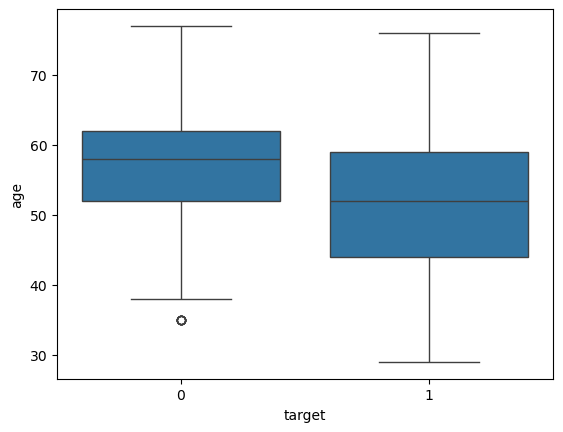

In [11]:
# BOXPLOT TO SEE AGE AND HEART DISEASE
sns.boxplot(x="target", y="age", data=df)
plt.show()

In [19]:
# SEPRATING INPUT FEATURES AND TARGET VARIBALE X,Y
X = df.drop("target", axis=1)
y = df["target"]

In [21]:
#TRAIN/TEST SPLIT  OF THE DATASET 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# MODEL USED LOGISTICREGRESSION AND TO TRAIN THE MODEL USING TRAINING DATA ON IT
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
# PREDICTING CLASS LABELS BASED ON 0 AND 1
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [36]:
# CALCULATING ACCURACY BASED ON THE DATASET
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7951219512195122


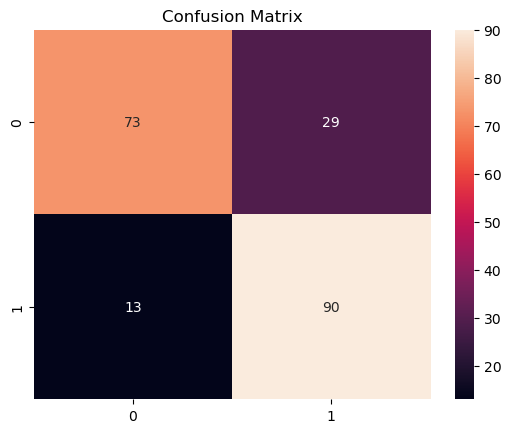

In [29]:
# CONFUSION MATRIX VISULIZATION
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

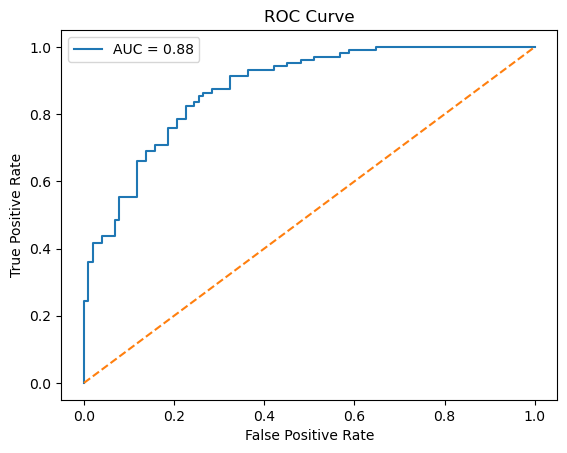

In [31]:
# ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

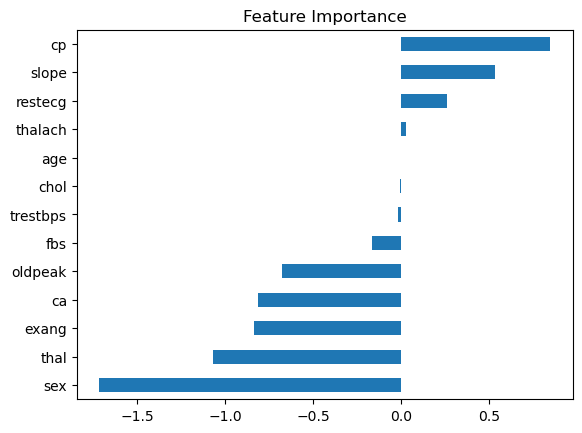

In [33]:
#EXTRACTING FEATURE IMPORTANT COFFICENTS
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [ ]:
## Results & Insights

- The model achieved good accuracy in predicting heart disease.
- Features like chest pain type, cholesterol, and maximum heart rate are important.
- ROC-AUC score indicates strong classification performance.
- Logistic Regression works well for this dataset due to linear separability.

## Conclusion
This model can assist in early detection of heart disease risk, but real-world use requires more data and validation.

In [40]:
# ROUGH WORK 
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Improved Accuracy:", accuracy_score(y_test, y_pred))

Improved Accuracy: 0.9853658536585366
